In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [34]:
df = pd.read_csv('data_for_test_10000 AGE.csv')

In [35]:
df.head()

,ID,Fullname,Birthday,Age,Sex,Hometown,Jobtype,Salary,Marital Status
0,123456789012,Nguyen Van A,12/09/1985,39,Male,Tra Vinh,Software Engineer,15,Married
1,123456789013,Nguyen Van Anh,15/08/1990,34,Male,Quang Nam,Software Engineer,500,Married
2,123456789014,Nguyen Van Anh,20/07/1985,39,Female,Hung Yen,Architect,700,Married
3,123456789015,Tran Thi Minh Thu,12/05/1987,37,Female,Thanh pho Can Tho,Architect,200,Married
4,123456789016,Nguyen Van A,20/03/1990,34,Male,Ba Ria - Vung Tau,Architect,500,Single


In [43]:
spend_pos_lst = []
for i in df['Salary']:
    if i < df['Salary'].mean():
        spend_pos_lst.append(i * 0.5)
    else:
        spend_pos_lst.append(i * 0.3)

df['Spending possibility'] = spend_pos_lst

df['Saving possibility'] = df['Salary'] * 0.15

savings_package = []
interst_month = []

for i in df['Saving possibility']:
    if i < 10:
        savings_package.append('Flexible savings package')
        interst_month.append(i * 0.0004)
    elif i >= 10 and i < 50:
        savings_package.append('Short-term savings package')
        interst_month.append(i * 0.003)
    else:
        savings_package.append('Long-term savings package')
        interst_month.append(i * 0.005)

df['Savings Package'] = savings_package
df['Interest/Month'] = interst_month

df.head()

,ID,Fullname,Birthday,Age,Sex,Hometown,Jobtype,Salary,Marital Status,Spending possibility,Saving possibility,Savings Package,Interest/Month
0,123456789012,Nguyen Van A,12/09/1985,39,Male,Tra Vinh,Software Engineer,15,Married,7.5,2.25,Flexible savings package,0.0009
1,123456789013,Nguyen Van Anh,15/08/1990,34,Male,Quang Nam,Software Engineer,500,Married,150.0,75.00,Long-term savings package,0.3750
2,123456789014,Nguyen Van Anh,20/07/1985,39,Female,Hung Yen,Architect,700,Married,210.0,105.00,Long-term savings package,0.5250
3,123456789015,Tran Thi Minh Thu,12/05/1987,37,Female,Thanh pho Can Tho,Architect,200,Married,100.0,30.00,Short-term savings package,0.0900
4,123456789016,Nguyen Van A,20/03/1990,34,Male,Ba Ria - Vung Tau,Architect,500,Single,150.0,75.00,Long-term savings package,0.3750


-Sau khi trừ tất cả chi phí đã dùng trong tháng, người có số tiền tiết kiệm dưới 10 triệu đồng/1 tháng có xu hướng sử dụng các gói gửi tiết kiệm không có thời hạn, linh hoạt để có thể rút ra và sử dụng bất cứ lúc nào. 

-Đối với người có số tiền tiết kiệm từ 10 - 50 triệu đồng/1 tháng có xu hướng sử dụng các gói gửi tiết kiệm có thời hạn ngắn(3-6 tháng) với mức lãi suất thấp( 4%/năm tương đương 0.003%/tháng)

-Cuối cùng, người có số tiền tiết kiệm trên 50 triệu đồng/1 tháng có xu hướng sử dụng các gói gửi tiết kiệm dùng các gói gửi tiết kiệm có thời hạn dài(trên 6 tháng) để tối đa hóa số tiền họ có với mức lãi suất khoảng 6%/năm(tương đương 0.0.5%/tháng).

In [39]:
def encodeDataset(data):

    categorical = data.select_dtypes(include = 'object')

    encoder = LabelEncoder()

    new_df = pd.DataFrame(index = range(9996))

    for i in categorical:
        le = (encoder.fit_transform(data[i]))
        le = pd.DataFrame(le).rename(columns = {0 : i})
        new_df = pd.concat([new_df, le], axis = 1)

    numerical = pd.concat([data.select_dtypes(include = 'int'), data.select_dtypes(include = 'float')], axis = 1)

    final_df = pd.concat([new_df, numerical], axis = 1)

    return final_df

In [40]:
new_df = encodeDataset(df)
new_df.head()

,Fullname,Birthday,Sex,Hometown,Jobtype,Marital Status,Savings Package,ID,Age,Salary,Spending possibility,Saving possibility,Interest/Month
0,331,703,1,57,98,1,0,123456789012,39,15,7.5,2.25,0.0009
1,333,1004,1,39,98,1,1,123456789013,34,500,150.0,75.00,0.3750
2,333,1458,0,23,4,1,1,123456789014,39,700,210.0,105.00,0.5250
3,569,630,0,50,4,1,2,123456789015,37,200,100.0,30.00,0.0900
4,331,1387,1,2,4,2,1,123456789016,34,500,150.0,75.00,0.3750


In [41]:
X = new_df.drop(columns = 'Interest/Month')
y = new_df['Interest/Month']

scaler = StandardScaler()
X_ss = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

ridge = Ridge()

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='r2')

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best model: {best_model}")

best_ridge = grid_search.best_estimator_
y_train_pred = best_ridge.predict(X_train)
y_test_pred = best_ridge.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Train Mean Squared Error: {mse_train}")
print(f"Test Mean Squared Error: {mse_test}")

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"Train R2 Score: {r2_train}")
print(f"Test R2 Score: {r2_test}")

if r2_train > r2_test and abs(r2_train - r2_test) > 0.1:
    print("Mô hình overfitting.")
elif r2_train < 0.6 and r2_test < 0.6:
    print("Mô hình underfitting.")
else:
    print("Mô hình hoạt động tốt.")

Best model: Ridge(alpha=100)
Train Mean Squared Error: 0.0001686823734293288
Test Mean Squared Error: 0.00016305524767855727
Train R2 Score: 0.9966479470408696
Test R2 Score: 0.9958170469335073
Mô hình hoạt động tốt.


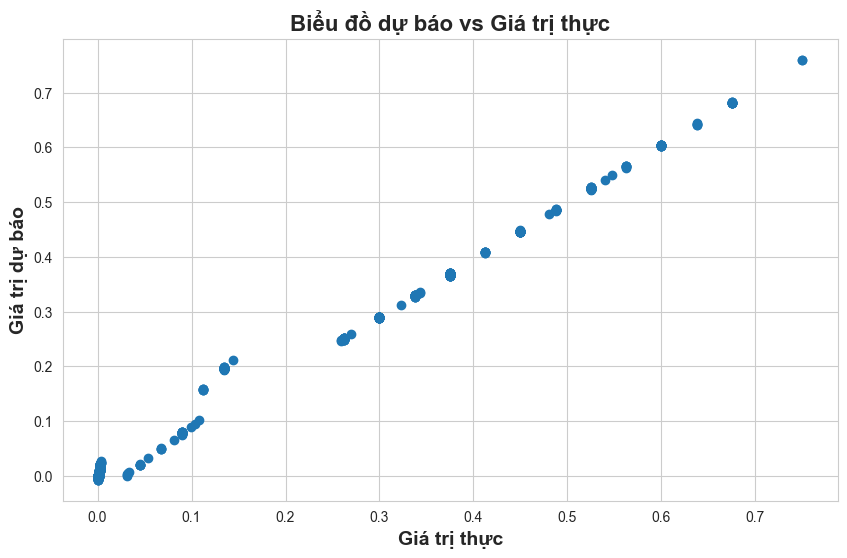

In [42]:
plt.figure(figsize = (10, 6))

plt.scatter(y_test, y_test_pred)
plt.xlabel('Giá trị thực', fontsize=14, fontweight='bold')
plt.ylabel('Giá trị dự báo', fontsize=14, fontweight='bold')
plt.title('Biểu đồ dự báo vs Giá trị thực', fontsize=16, fontweight='bold')
plt.show()